In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lmfit import Model
import pathlib as Path
from scipy.signal import savgol_filter

In [2]:
from pathlib import Path
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_08_17_data_timeseries.csv')
df = pd.read_csv(x).drop(columns='Unnamed: 0')
df

,condition_id,condition,category,valence,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix),RDX_rolling,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad
0,ACP_10,ACP,objet,negative,0.000000,-0.203103,10.545351,-1.557942,7.259980,-1.557942,-44.339866,329.0,-12.022054,1655.0,0.015888
1,ACP_10,ACP,objet,negative,0.003335,0.411109,11.118102,-0.912476,7.956384,-1.235209,-44.339866,329.0,-12.022054,1655.0,0.015888
2,ACP_10,ACP,objet,negative,0.006670,1.032096,11.620336,-0.216857,8.562834,-0.895758,-44.339866,329.0,-12.022054,1655.0,0.015888
3,ACP_10,ACP,objet,negative,0.010006,1.631694,11.941326,0.494356,8.978518,-0.548230,-44.339866,329.0,-12.022054,1655.0,0.015888
4,ACP_10,ACP,objet,negative,0.013341,2.171882,11.973220,1.177103,9.107632,-0.203163,-44.339866,329.0,-12.022054,1655.0,0.015888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933627,DFT_9,DFT,visage,positive,5.959993,NaN,NaN,-23.547614,NaN,-23.149807,-48.965409,317.0,-13.618955,1256.0,0.028713
933628,DFT_9,DFT,visage,positive,5.963328,NaN,NaN,-24.026216,NaN,-23.152393,-48.965409,317.0,-13.618955,1256.0,0.028713
933629,DFT_9,DFT,visage,positive,5.966663,NaN,NaN,-24.564667,NaN,-23.182579,-48.965409,317.0,-13.618955,1256.0,0.028713
933630,DFT_9,DFT,visage,positive,5.969998,NaN,NaN,-25.144319,NaN,-23.244083,-48.965409,317.0,-13.618955,1256.0,0.028713


##### Remove NaNs

In [3]:
rdx_data = df.dropna(subset=['RDX_rolling'], how='any')
rdx_data

,condition_id,condition,category,valence,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix),RDX_rolling,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad
0,ACP_10,ACP,objet,negative,0.000000,-0.203103,10.545351,-1.557942,7.259980,-1.557942,-44.339866,329.0,-12.022054,1655.0,0.015888
1,ACP_10,ACP,objet,negative,0.003335,0.411109,11.118102,-0.912476,7.956384,-1.235209,-44.339866,329.0,-12.022054,1655.0,0.015888
2,ACP_10,ACP,objet,negative,0.006670,1.032096,11.620336,-0.216857,8.562834,-0.895758,-44.339866,329.0,-12.022054,1655.0,0.015888
3,ACP_10,ACP,objet,negative,0.010006,1.631694,11.941326,0.494356,8.978518,-0.548230,-44.339866,329.0,-12.022054,1655.0,0.015888
4,ACP_10,ACP,objet,negative,0.013341,2.171882,11.973220,1.177103,9.107632,-0.203163,-44.339866,329.0,-12.022054,1655.0,0.015888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933627,DFT_9,DFT,visage,positive,5.959993,NaN,NaN,-23.547614,NaN,-23.149807,-48.965409,317.0,-13.618955,1256.0,0.028713
933628,DFT_9,DFT,visage,positive,5.963328,NaN,NaN,-24.026216,NaN,-23.152393,-48.965409,317.0,-13.618955,1256.0,0.028713
933629,DFT_9,DFT,visage,positive,5.966663,NaN,NaN,-24.564667,NaN,-23.182579,-48.965409,317.0,-13.618955,1256.0,0.028713
933630,DFT_9,DFT,visage,positive,5.969998,NaN,NaN,-25.144319,NaN,-23.244083,-48.965409,317.0,-13.618955,1256.0,0.028713


##### One hot encoder

In [4]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
ohetransform = ohe.fit_transform(rdx_data[['category', 'valence']])
rdx_data = pd.concat([rdx_data, ohetransform], axis=1).drop(columns=['category', 'valence'])

In [5]:
rdx_data

,condition_id,condition,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix),RDX_rolling,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad,category_objet,category_visage,valence_negative,valence_neutre,valence_positive
0,ACP_10,ACP,0.000000,-0.203103,10.545351,-1.557942,7.259980,-1.557942,-44.339866,329.0,-12.022054,1655.0,0.015888,1.0,0.0,1.0,0.0,0.0
1,ACP_10,ACP,0.003335,0.411109,11.118102,-0.912476,7.956384,-1.235209,-44.339866,329.0,-12.022054,1655.0,0.015888,1.0,0.0,1.0,0.0,0.0
2,ACP_10,ACP,0.006670,1.032096,11.620336,-0.216857,8.562834,-0.895758,-44.339866,329.0,-12.022054,1655.0,0.015888,1.0,0.0,1.0,0.0,0.0
3,ACP_10,ACP,0.010006,1.631694,11.941326,0.494356,8.978518,-0.548230,-44.339866,329.0,-12.022054,1655.0,0.015888,1.0,0.0,1.0,0.0,0.0
4,ACP_10,ACP,0.013341,2.171882,11.973220,1.177103,9.107632,-0.203163,-44.339866,329.0,-12.022054,1655.0,0.015888,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933627,DFT_9,DFT,5.959993,NaN,NaN,-23.547614,NaN,-23.149807,-48.965409,317.0,-13.618955,1256.0,0.028713,0.0,1.0,0.0,0.0,1.0
933628,DFT_9,DFT,5.963328,NaN,NaN,-24.026216,NaN,-23.152393,-48.965409,317.0,-13.618955,1256.0,0.028713,0.0,1.0,0.0,0.0,1.0
933629,DFT_9,DFT,5.966663,NaN,NaN,-24.564667,NaN,-23.182579,-48.965409,317.0,-13.618955,1256.0,0.028713,0.0,1.0,0.0,0.0,1.0
933630,DFT_9,DFT,5.969998,NaN,NaN,-25.144319,NaN,-23.244083,-48.965409,317.0,-13.618955,1256.0,0.028713,0.0,1.0,0.0,0.0,1.0


##### Train, test, split

In [100]:
from sklearn.model_selection import GroupShuffleSplit

X = rdx_data.loc[:, ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad', 'category_objet',  'category_visage', 'valence_negative',
   'valence_neutre', 'valence_positive']].iloc[0::1792, :].reset_index().drop(columns='index')
y = rdx_data.loc[:, 'condition'].iloc[0::1792].reset_index().drop(columns='index')

id = rdx_data.condition_id.iloc[0::1792].reset_index().drop(columns='index')

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in gss.split(X, groups=id):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

### Information of dataset
- there are 87 participants and at this time 5 variables (17 Aug)


### Data preperation steps
split the data in 80/20,
cross validation (CV)

1. Cleaning data
- Missing data
- Outliers
2. Formating
- Encoding categorical data
- Scaling data
- Standardization
- Discretization (binning data)
3. Data engineering

### Cleaning data

##### Missing data

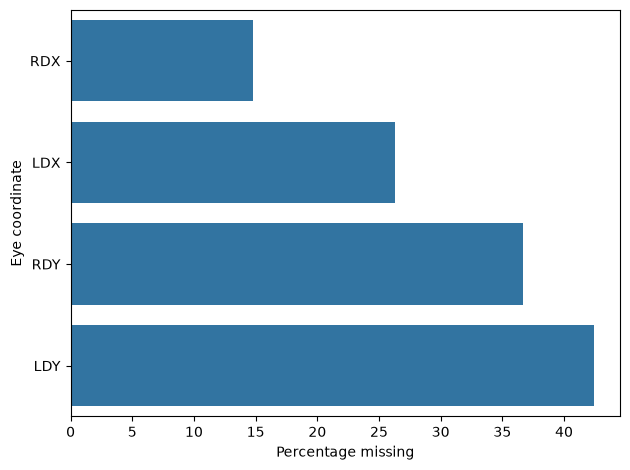

In [109]:
# highlight why RDX was chosen over the others
missing_values = {
    'RDX': df['RDX (pix)'].isna().mean()*100,
    'LDX': df['LDX (pix)'].isna().mean()*100,
    'RDY': df['RDY (pix)'].isna().mean()*100,
    'LDY': df['LDY (pix)'].isna().mean()*100
}


ax = sns.barplot(data = missing_values, orient='h')
ax.set(xlabel = 'Percentage missing', ylabel='Eye coordinate')

plt.savefig('figures/missing_pupil.png', dpi=150)
plt.tight_layout()

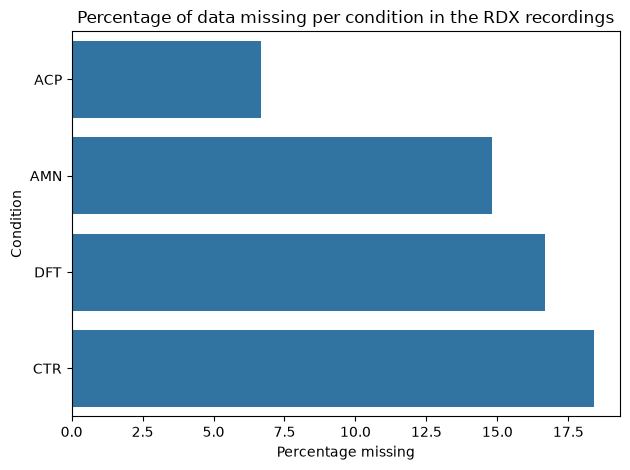

In [111]:
missing_values = {
    'ACP': df[df.condition=='ACP']['RDX (pix)'].isna().mean()*100,
    'AMN': df[df.condition=='AMN']['RDX (pix)'].isna().mean()*100,
    'DFT': df[df.condition=='DFT']['RDX (pix)'].isna().mean()*100,
    'CTR': df[df.condition=='CTR']['RDX (pix)'].isna().mean()*100
}


ax = sns.barplot(data = missing_values, orient='h')
ax.set(xlabel='Percentage missing', ylabel='Condition', title='Percentage of data missing per condition in the RDX recordings')
plt.savefig('figures/missing_rdx.png', dpi=150)
plt.tight_layout()

##### Outliers

In [15]:
df

,condition_id,condition,category,valence,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix),RDX_rolling,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad
0,ACP_10,ACP,objet,negative,0.000000,-0.203103,10.545351,-1.557942,7.259980,-1.557942,-44.339866,329.0,-12.022054,1655.0,0.015888
1,ACP_10,ACP,objet,negative,0.003335,0.411109,11.118102,-0.912476,7.956384,-1.235209,-44.339866,329.0,-12.022054,1655.0,0.015888
2,ACP_10,ACP,objet,negative,0.006670,1.032096,11.620336,-0.216857,8.562834,-0.895758,-44.339866,329.0,-12.022054,1655.0,0.015888
3,ACP_10,ACP,objet,negative,0.010006,1.631694,11.941326,0.494356,8.978518,-0.548230,-44.339866,329.0,-12.022054,1655.0,0.015888
4,ACP_10,ACP,objet,negative,0.013341,2.171882,11.973220,1.177103,9.107632,-0.203163,-44.339866,329.0,-12.022054,1655.0,0.015888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933627,DFT_9,DFT,visage,positive,5.959993,NaN,NaN,-23.547614,NaN,-23.149807,-48.965409,317.0,-13.618955,1256.0,0.028713
933628,DFT_9,DFT,visage,positive,5.963328,NaN,NaN,-24.026216,NaN,-23.152393,-48.965409,317.0,-13.618955,1256.0,0.028713
933629,DFT_9,DFT,visage,positive,5.966663,NaN,NaN,-24.564667,NaN,-23.182579,-48.965409,317.0,-13.618955,1256.0,0.028713
933630,DFT_9,DFT,visage,positive,5.969998,NaN,NaN,-25.144319,NaN,-23.244083,-48.965409,317.0,-13.618955,1256.0,0.028713


<Axes: xlabel='RDX_min', ylabel='RDX_lat_min'>

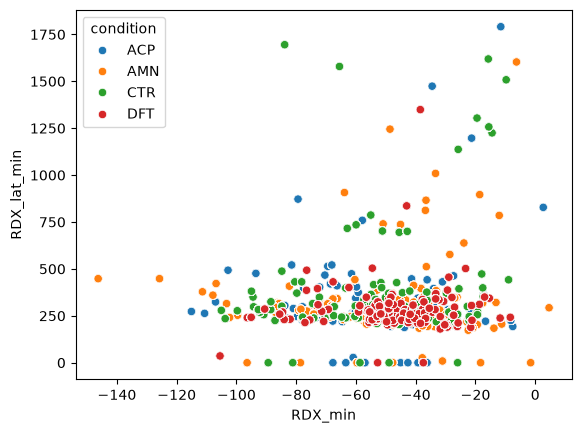

In [25]:
sns.scatterplot(df, x='RDX_min', y='RDX_lat_min', hue='condition')

<Axes: xlabel='RDX_max', ylabel='RDX_lat_max'>

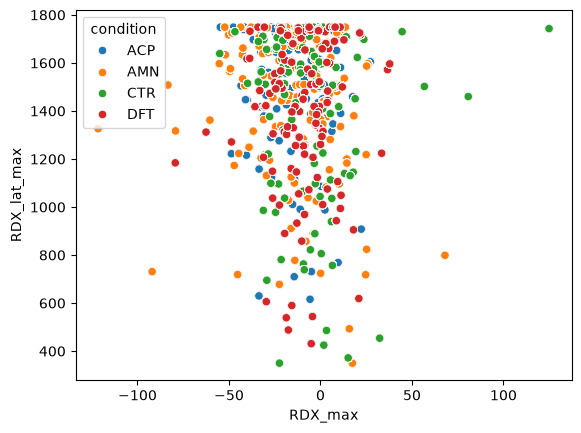

In [26]:
sns.scatterplot(df, x='RDX_max', y='RDX_lat_max', hue='condition')